# Ensemble Methods (Ансамбли)

In [415]:
import os
import time
from collections import Counter
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit,
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder, TargetEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, StackingRegressor,
    RandomForestClassifier, AdaBoostClassifier, StackingClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    mean_absolute_error, root_mean_squared_error, r2_score,
    make_scorer, mean_absolute_percentage_error, roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Source

import shap
import optuna

import lightgbm as lgb
import catboost as cb
import xgboost as xgb

In [416]:
RANDOM_STATE = 21

dataset_dir_path = "../../../datasets"

In [417]:
def eval_model(y_true, y_pred, mode='regression'):
    if mode == "regression":
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics = {
            "rmse": [rmse],
            "mae": [mae],
            "r2": [r2]
        }
    elif mode == "classification":
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')

        metrics = {
            "accuracy": [accuracy],
            "f1": [f1],
            "precision": [precision],
            "recall": [recall],
            "roc_auc": [roc_auc],
        }
    else:
        metrics = {}

    return metrics

## Задание 1: Сравнение ансамблей

### Описание:
Вы — исследователь данных в компании, которая занимается прогнозированием спроса на продукты. Вам нужно сравнить эффективность различных ансамблевых методов:


Bagging (например, Random Forest)

Boosting (например, AdaBoost)
Stacking
Требования:

Выберите датасет (например, Kaggle: Store Item Demand Forecasting).
Постройте модели с использованием каждого из методов.
Сравните их по метрикам (RMSE, MAE, R² для регрессии или accuracy, F1-score для классификации).
Проанализируйте, какой метод показал лучшие результаты и почему.
Дополнительно:

Попробуйте настроить гиперпараметры для каждой модели.


In [418]:
data_dir_path = "../../../datasets/grocery_store_sales"
dataset_file_path = os.path.join(data_dir_path, "grocery_chain_data.json")

# https://www.kaggle.com/c/demand-forecasting-kernels-only

df = pd.read_json(dataset_file_path, convert_dates=['transaction_date'])

df.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22


In [419]:
df["store_name"].value_counts(normalize=True)

store_name
City Fresh Store      0.120205
SuperSave Central     0.118670
ValuePlus Market      0.113043
GreenGrocer Plaza     0.112532
Corner Grocery        0.111509
FamilyFood Express    0.109974
MegaMart Westside     0.109463
QuickStop Market      0.106394
FreshMart Downtown    0.098210
Name: proportion, dtype: float64

In [420]:
df["aisle"].value_counts(normalize=True)

aisle
Beverages            0.098485
Personal Care        0.096970
Snacks & Candy       0.095960
Canned Goods         0.095960
Frozen Foods         0.094949
Health & Wellness    0.092424
Bakery               0.091919
Household Items      0.088384
Dairy                0.082828
Meat & Seafood       0.081313
Produce              0.080808
Name: proportion, dtype: float64

In [421]:
df["product_name"].value_counts(normalize=True)

product_name
Chicken Breast    0.066162
Onions            0.064141
Tomatoes          0.063636
Bread             0.061111
Potatoes          0.059596
Eggs              0.057576
Salmon            0.057071
Cereal            0.057071
Orange Juice      0.056566
Yogurt            0.055051
Milk              0.054545
Cheese            0.053030
Apples            0.052020
Bananas           0.051515
Pasta             0.050000
Rice              0.049495
Carrots           0.046465
Ground Beef       0.044949
Name: proportion, dtype: float64

In [422]:
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [423]:
df.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points,year,month,day_of_week,is_weekend
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2,7.46,14.92,0.00,14.92,377,2023,8,5,1
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111,2024,2,1,0
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4,7.38,29.52,4.04,25.48,301,2023,11,3,0
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490,2025,1,0,0
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22,2023,10,4,0


In [424]:
X = df.drop(columns=["quantity", "transaction_date"]).copy()
y = df.loc[:, "quantity"].copy().astype(float)

In [425]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=RANDOM_STATE)

In [426]:
ohe = OneHotEncoder(handle_unknown='ignore')
X_train_enc = ohe.fit_transform(X_train)
X_test_enc = ohe.transform(X_test)

In [427]:
# le = LabelEncoder()
# y_train_enc = le.fit_transform(y_train)
# y_test_enc = le.transform(y_test)

In [428]:
xgbr = xgb.XGBRegressor(n_estimators=3, random_state=RANDOM_STATE)
rfc = RandomForestRegressor(n_estimators=3, random_state=RANDOM_STATE)
adabc = AdaBoostRegressor(estimator=RandomForestRegressor(n_estimators=3, random_state=RANDOM_STATE))
sc = StackingRegressor(estimators=[
    ('rfc', RandomForestRegressor(n_estimators=3, random_state=RANDOM_STATE)),
    ('lr', xgb.XGBRegressor(n_estimators=3, random_state=RANDOM_STATE)),
])

models = {
    'XGBoost': xgbr,
    'RandomForest (Bagging)': rfc,
    'AdaBoost (Boosting)': adabc,
    'Stacking': sc
}

In [429]:
res_metrics_df = pd.DataFrame()

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_test_enc)
    
    metrics = eval_model(y_test, y_pred, mode='regression')
    mdf = pd.DataFrame({
        "model": [name],
        **metrics
    })
    res_metrics_df = pd.concat([res_metrics_df, mdf])

In [430]:
res_metrics_df

,model,rmse,mae,r2
0,XGBoost,1.419747,1.215650,-0.013851
0,RandomForest (Bagging),1.672884,1.395623,-0.407614
0,AdaBoost (Boosting),1.513501,1.289562,-0.152172
0,Stacking,1.412592,1.210376,-0.003657


# Gradient Boosting (Градиентный бустинг)

## Задание 1: Прогнозирование оттока клиентов

### Описание:
Телекоммуникационная компания хочет предсказать, какие клиенты могут уйти к конкурентам. Вам нужно построить модель на основе градиентного бустинга.
Требования:

Используйте датасет Telco Customer Churn.
Постройте модель с использованием GradientBoostingClassifier из sklearn.
Оцените модель с помощью метрик: accuracy, precision, recall, ROC-AUC.
Проанализируйте важность признаков.
Дополнительно:

Попробуйте использовать XGBoost или LightGBM и сравните результаты.


In [431]:
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [432]:
dataset_file_path = os.path.join(dataset_dir_path, "telco_customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(dataset_file_path, index_col="customerID", na_values=[' '])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [433]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null 

In [434]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [435]:
X = df.drop(columns='Churn').copy()
y = df.loc[:, "Churn"].copy()

In [436]:
num_features = X.select_dtypes("number").columns.tolist()
cat_features = X.select_dtypes("object").columns.tolist()

print(num_features)
print(cat_features)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [437]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

In [438]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("cat", numeric_transformer, num_features),
    ("num", categorical_transformer, cat_features)
], remainder='passthrough')

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [439]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [440]:
gbc = GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_STATE)
gbc.fit(X_train_enc, y_train_enc)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [441]:
y_pred = gbc.predict(X_test_enc)
metrics = eval_model(y_test_enc, y_pred, mode="classification")

res_metrics_df = pd.DataFrame({
    "model": str(gbc),
    **metrics
})

res_metrics_df

,model,accuracy,f1,precision,recall,roc_auc
0,"GradientBoostingClassifier(n_estimators=50, ra...",0.792239,0.708606,0.645238,0.483066,0.69353


In [442]:
cbc = cb.CatBoostClassifier(n_estimators=50, random_seed=RANDOM_STATE)
lgbc = lgb.LGBMClassifier(n_estimators=50, random_state=RANDOM_STATE)
xgbc = xgb.XGBClassifier(n_estimators=50, random_state=RANDOM_STATE)

models = {
    "CatBoost": cbc,
    "LGB": lgbc,
    "XGB": xgbc
}

In [443]:
res_metrics_df = pd.DataFrame()

for name, model in models.items():

    model.fit(X_train_enc, y_train_enc)
    y_pred = model.predict(X_test_enc)

    metrics = eval_model(y_test_enc, y_pred, mode="classification")

    metrics_df = pd.DataFrame({
        "model": name,
        **metrics
    })
    res_metrics_df = pd.concat([res_metrics_df, metrics_df])

res_metrics_df

Learning rate set to 0.317559
0:	learn: 0.5218925	total: 3.56ms	remaining: 174ms
1:	learn: 0.4646500	total: 6.96ms	remaining: 167ms
2:	learn: 0.4313283	total: 10.4ms	remaining: 163ms
3:	learn: 0.4120335	total: 15.1ms	remaining: 174ms
4:	learn: 0.4029533	total: 19.3ms	remaining: 174ms
5:	learn: 0.3960123	total: 24.5ms	remaining: 180ms
6:	learn: 0.3913897	total: 29.5ms	remaining: 181ms
7:	learn: 0.3863835	total: 34ms	remaining: 178ms
8:	learn: 0.3823582	total: 37.4ms	remaining: 170ms
9:	learn: 0.3797362	total: 40.5ms	remaining: 162ms
10:	learn: 0.3771345	total: 44ms	remaining: 156ms
11:	learn: 0.3741488	total: 48.4ms	remaining: 153ms
12:	learn: 0.3716169	total: 51.5ms	remaining: 147ms
13:	learn: 0.3683330	total: 54.5ms	remaining: 140ms
14:	learn: 0.3663409	total: 57.4ms	remaining: 134ms
15:	learn: 0.3638176	total: 60.7ms	remaining: 129ms
16:	learn: 0.3617646	total: 64.5ms	remaining: 125ms
17:	learn: 0.3598225	total: 68.3ms	remaining: 121ms
18:	learn: 0.3583110	total: 71.7ms	remaining: 11

c:\main\data_science\projects\ml_practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,f1,precision,recall,roc_auc
0,CatBoost,0.787506,0.710071,0.621739,0.509804,0.698845
0,LGB,0.799811,0.723511,0.656109,0.516934,0.709498
0,XGB,0.784193,0.704959,0.614880,0.500891,0.693745


In [444]:
importances = gbc.feature_importances_
importance_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'importance': importances
}).sort_values("importance", ascending=False).head(10)

importance_df

,feature,importance
36,num__Contract_Month-to-month,0.392386
1,cat__tenure,0.175128
27,num__TechSupport_No,0.075068
16,num__InternetService_Fiber optic,0.070570
2,cat__MonthlyCharges,0.064063
18,num__OnlineSecurity_No,0.063663
3,cat__TotalCharges,0.049229
43,num__PaymentMethod_Electronic check,0.040644
38,num__Contract_Two year,0.011509
12,num__MultipleLines_No,0.009356


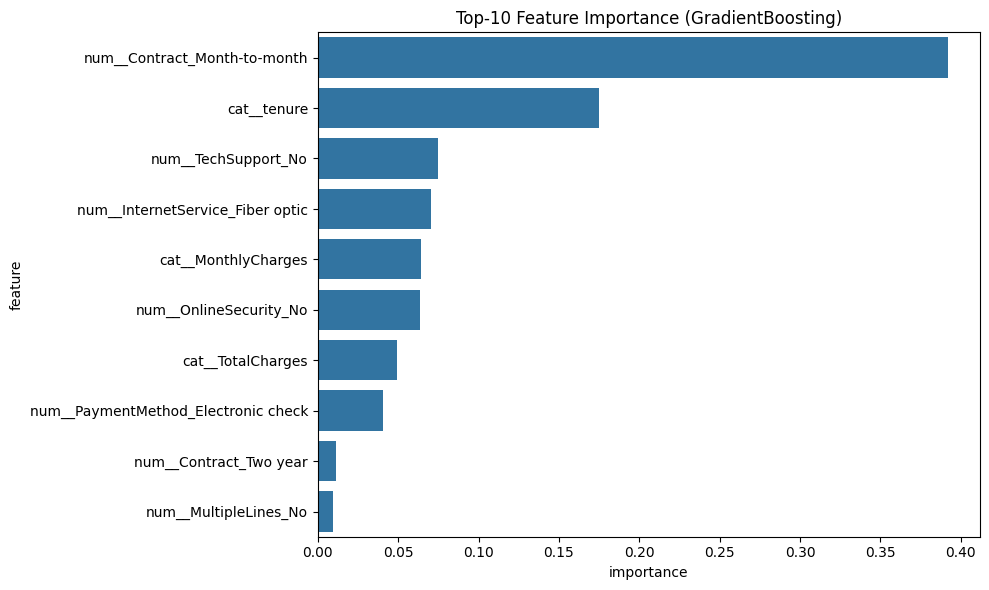

In [445]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.title('Top-10 Feature Importance (GradientBoosting)')
plt.tight_layout()
plt.show()

# Modern Gradient Boosting Implementations (Современные реализации градиентного бустинга)

## Задание 2: Сравнение XGBoost, LightGBM и CatBoost

### Описание:
Вы — участник соревнования на Kaggle. Вам нужно выбрать лучшую модель для задачи регрессии или классификации.
Требования:

Выберите датасет (например, House Prices: Advanced Regression Techniques).
Постройте модели с использованием:

XGBoost
LightGBM
CatBoost

Сравните их по метрикам (RMSE, MAE, R² для регрессии или accuracy, F1-score для классификации).
Проанализируйте скорость обучения и предсказания каждой модели.
Дополнительно:

Попробуйте настроить гиперпараметры для каждой модели с помощью Optuna или GridSearchCV.


In [446]:
# https://www.kaggle.com/c/house-prices-advanced-regression-techniques

In [447]:
dataset_file_path = os.path.join(dataset_dir_path, "house_prices_advanced_regression_techniques")

df_train = pd.read_csv(os.path.join(dataset_file_path, "train.csv"), index_col='Id')
df_test = pd.read_csv(os.path.join(dataset_file_path, "test.csv"), index_col='Id')

df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [448]:
df_train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [449]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [450]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt 

In [451]:
threshold = 0.95

df_train = df_train.loc[:, df_train.isnull().sum() / len(df_train) < threshold]
df_test = df_test.loc[:, df_test.isnull().sum() / len(df_test) < threshold]

In [452]:
X_train_val = df_train.drop(columns="SalePrice").copy()
y_train_val = df_train.loc[:, "SalePrice"].copy()

X_test = df_test.copy()

In [453]:
y_train_val = np.log1p(y_train_val)

In [454]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, random_state=RANDOM_STATE)

In [455]:
num_features = X_train_val.select_dtypes("number").columns.tolist()
cat_features = X_train_val.select_dtypes("object").columns.tolist()

print(num_features)
print(cat_features)

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCon

In [456]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
], remainder="passthrough")

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

In [457]:
# scaler = StandardScaler()

# y_train_scaled = scaler.fit_transform(y_train)
# y_val_scaled = scaler.transform(y_val)

In [458]:
cbr = cb.CatBoostRegressor()
xgbr = xgb.XGBRegressor()
lgbr = lgb.LGBMRegressor()

models = {
    "CatBoost": cbr,
    "XGB": xgbr,
    "LGB": lgbr,
}

In [461]:
res_metrics_df = pd.DataFrame()

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_val_enc)

    y_val_ = np.expm1(y_val)
    y_pred_ = np.expm1(y_pred)

    metrics = eval_model(y_val_, y_pred_)
    metrics_df = pd.DataFrame({
        "model": name,
        **metrics,
    })
    res_metrics_df = pd.concat([res_metrics_df, metrics_df])

res_metrics_df

Learning rate set to 0.041084
0:	learn: 0.3824232	total: 3.2ms	remaining: 3.19s
1:	learn: 0.3727997	total: 7.53ms	remaining: 3.75s
2:	learn: 0.3628910	total: 12.2ms	remaining: 4.06s
3:	learn: 0.3537034	total: 16.1ms	remaining: 4.02s
4:	learn: 0.3445627	total: 19.8ms	remaining: 3.93s
5:	learn: 0.3365877	total: 23.8ms	remaining: 3.94s
6:	learn: 0.3288821	total: 28.7ms	remaining: 4.08s
7:	learn: 0.3207295	total: 33.4ms	remaining: 4.13s
8:	learn: 0.3132882	total: 37.3ms	remaining: 4.1s
9:	learn: 0.3060668	total: 41.7ms	remaining: 4.13s
10:	learn: 0.2985865	total: 45.7ms	remaining: 4.11s
11:	learn: 0.2915234	total: 49.4ms	remaining: 4.07s
12:	learn: 0.2849386	total: 52.6ms	remaining: 4s
13:	learn: 0.2785599	total: 56.6ms	remaining: 3.98s
14:	learn: 0.2727485	total: 60.3ms	remaining: 3.96s
15:	learn: 0.2671474	total: 63.4ms	remaining: 3.9s
16:	learn: 0.2614294	total: 66.7ms	remaining: 3.85s
17:	learn: 0.2561185	total: 69.9ms	remaining: 3.81s
18:	learn: 0.2512044	total: 74.3ms	remaining: 3.83

c:\main\data_science\projects\ml_practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,rmse,mae,r2
0,CatBoost,35721.373492,15222.250298,0.795211
0,XGB,33998.300121,18512.282677,0.814491
0,LGB,34355.630175,16798.744474,0.810571


In [462]:
importances = xgbr.feature_importances_
importance_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'importance': importances
}).sort_values("importance", ascending=False).head(10)

importance_df

,feature,importance
3,num__OverallQual,0.231079
25,num__GarageCars,0.105013
214,cat__CentralAir_N,0.072772
176,cat__BsmtQual_Ex,0.049890
45,cat__Alley_missing,0.042751
40,cat__MSZoning_RM,0.039553
15,num__GrLivArea,0.032666
117,cat__HouseStyle_SLvl,0.022233
239,cat__GarageType_Attchd,0.017990
223,cat__KitchenQual_Gd,0.015758


C:\Users\Tumbi\AppData\Local\Temp\ipykernel_6572\1382752296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(), y="feature", x="importance", palette='viridis')


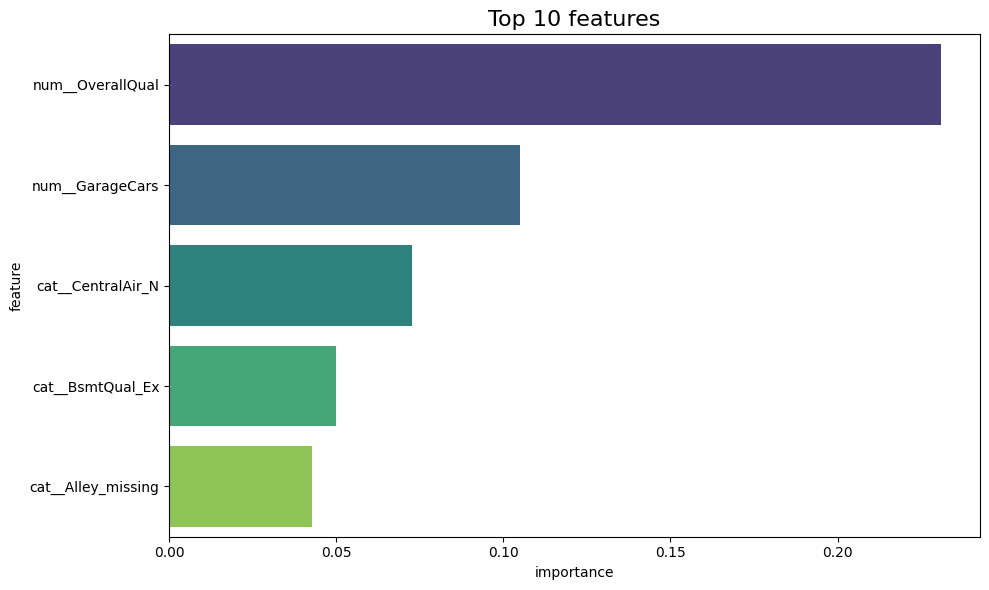

In [467]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(), y="feature", x="importance", palette='viridis')
plt.title("Top 10 features", fontsize=16)
plt.tight_layout()
plt.show()

## Задание 3: Оптимизация гиперпараметров для CatBoost

### Описание:
Вы работаете над задачей предсказания качества вина. Вам нужно оптимизировать гиперпараметры для CatBoost.
Требования:

Используйте датасет Wine Quality.
Постройте модель CatBoost для классификации качества вина.
Оптимизируйте гиперпараметры с помощью Optuna.
Оцените модель с помощью метрик: accuracy, F1-score, ROC-AUC.
Дополнительно:

Визуализируйте важность признаков.


In [ ]:
# https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009